In [1]:
import subprocess, sys
def pip(*p): subprocess.run([sys.executable,'-m','pip','install','-q',*p], check=True)
pip('ultralytics==8.3.*','easyocr','opencv-python-headless','tqdm','basicsr','realesrgan')
print("✓ Done")

from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.7/344.7 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 23.5 MB/s eta 0:00:00
✓ Done
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/q

In [2]:
# ============================================================
# 1. CONFIGURATION
# ============================================================

MODEL_PATH = Path(
    "/kaggle/input/notebooks/tanvirmahtabtaneem/ocr-model/bangla_lpdb_runs/bangla_lpdb_yolo11m_t4x2/weights/best.pt"
)

DATASET_ROOT = Path(
    "/kaggle/input/datasets/tanvirmahtabtaneem/ocr-dataset/Bangla LPDB - A/Bangla_License_Plate"
)

CLASS_FILE = DATASET_ROOT / "classes.txt"

IMAGE_FILES = sorted(
    p for p in DATASET_ROOT.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
)

OUTPUT_ROOT = Path(
    "/kaggle/working/bangla_ocr_inference"
)

VIS_DIR = OUTPUT_ROOT / "visualizations"

RESULT_CSV = OUTPUT_ROOT / "results.csv"

CONF_THRESHOLD = 0.25
DEVICE = 0
MAX_VISUALIZATIONS = 30


In [3]:
# ============================================================
# 2. CHECK PATHS
# ============================================================

print("=" * 70)
print("CHECKING FILES")
print("=" * 70)

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Trained model not found:\n{MODEL_PATH}"
    )

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset not found:\n{DATASET_ROOT}"
    )

if not CLASS_FILE.exists():
    raise FileNotFoundError(
        f"classes.txt not found:\n{CLASS_FILE}"
    )

print("Model:", MODEL_PATH)
print("Dataset:", DATASET_ROOT)
print("Images:", len(IMAGE_FILES))

CHECKING FILES
Model: /kaggle/input/notebooks/tanvirmahtabtaneem/ocr-model/bangla_lpdb_runs/bangla_lpdb_yolo11m_t4x2/weights/best.pt
Dataset: /kaggle/input/datasets/tanvirmahtabtaneem/ocr-dataset/Bangla LPDB - A/Bangla_License_Plate
Images: 2668


In [4]:
# ============================================================
# 3. LOAD CLASS NAMES
# ============================================================

class_names = [
    x.strip()
    for x in CLASS_FILE.read_text(
        encoding="utf-8",
        errors="ignore"
    ).splitlines()
    if x.strip()
]

print("\nNumber of classes:", len(class_names))

if len(class_names) != 102:
    print(
        "WARNING: expected 102 classes, "
        f"found {len(class_names)}."
    )


Number of classes: 102


In [5]:
# ============================================================
# 4. LOAD TRAINED MODEL
# ============================================================

print("\nLoading trained model...")

model = YOLO(str(MODEL_PATH))

print("Model loaded successfully.")


Loading trained model...
Model loaded successfully.


In [6]:
# ============================================================
# 5. OUTPUT FOLDERS
# ============================================================

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

VIS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [7]:
# ============================================================
# 6. DETECTIONS
# ============================================================

def detect_tokens(
    result,
    confidence_threshold=0.25
):

    detections = []

    if result.boxes is None:
        return detections

    for i in range(len(result.boxes)):

        confidence = float(
            result.boxes.conf[i].item()
        )

        if confidence < confidence_threshold:
            continue

        class_id = int(
            result.boxes.cls[i].item()
        )

        if (
            class_id < 0
            or class_id >= len(class_names)
        ):
            continue

        x1, y1, x2, y2 = (
            result.boxes.xyxy[i]
            .cpu()
            .numpy()
            .tolist()
        )

        cx = (x1 + x2) / 2.0
        cy = (y1 + y2) / 2.0

        width = x2 - x1
        height = y2 - y1

        detections.append({
            "class_id": class_id,
            "name": class_names[class_id],
            "confidence": confidence,
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "cx": cx,
            "cy": cy,
            "width": width,
            "height": height
        })

    return detections

In [8]:
# ============================================================
# 7. GROUP DETECTIONS INTO ROWS
# ============================================================

def group_into_rows(detections):

    if not detections:
        return []

    detections = sorted(
        detections,
        key=lambda x: x["cy"]
    )

    rows = []

    for detection in detections:

        placed = False

        for row in rows:

            row_y = np.mean([
                x["cy"]
                for x in row
            ])

            row_height = np.mean([
                x["height"]
                for x in row
            ])

            tolerance = 0.55 * row_height

            if abs(
                detection["cy"] - row_y
            ) <= tolerance:

                row.append(detection)
                placed = True
                break

        if not placed:
            rows.append([detection])

    rows.sort(
        key=lambda row: np.mean([
            x["cy"]
            for x in row
        ])
    )

    for row in rows:
        row.sort(
            key=lambda x: x["cx"]
        )

    return rows


def flatten_rows(rows):

    ordered = []

    for row in rows:
        ordered.extend(row)

    return ordered


def token_sequence(ordered):

    return [
        item["name"]
        for item in ordered
    ]

In [9]:
# ============================================================
# 8. READ GROUND-TRUTH TOKENS
# ============================================================

def read_ground_truth(label_path):

    tokens = []

    if not label_path.exists():
        return tokens

    lines = label_path.read_text(
        encoding="utf-8",
        errors="ignore"
    ).splitlines()

    for line in lines:

        parts = line.split()

        if len(parts) != 5:
            continue

        try:
            class_id = int(float(parts[0]))
            x = float(parts[1])
            y = float(parts[2])
            w = float(parts[3])
            h = float(parts[4])
        except ValueError:
            continue

        if (
            class_id < 0
            or class_id >= len(class_names)
        ):
            continue

        tokens.append({
            "class_id": class_id,
            "name": class_names[class_id],
            "cx": x,
            "cy": y,
            "width": w,
            "height": h
        })

    if not tokens:
        return tokens

    # Top to bottom
    tokens.sort(
        key=lambda x: x["cy"]
    )

    rows = []

    for token in tokens:

        placed = False

        for row in rows:

            row_y = np.mean([
                x["cy"]
                for x in row
            ])

            if abs(
                token["cy"] - row_y
            ) <= 0.08:

                row.append(token)
                placed = True
                break

        if not placed:
            rows.append([token])

    rows.sort(
        key=lambda row: np.mean([
            x["cy"]
            for x in row
        ])
    )

    for row in rows:
        row.sort(
            key=lambda x: x["cx"]
        )

    return flatten_rows(rows)

In [10]:
# ============================================================
# 9. EDIT DISTANCE
# ============================================================

def levenshtein(a, b):

    n = len(a)
    m = len(b)

    dp = [
        [0] * (m + 1)
        for _ in range(n + 1)
    ]

    for i in range(n + 1):
        dp[i][0] = i

    for j in range(m + 1):
        dp[0][j] = j

    for i in range(1, n + 1):

        for j in range(1, m + 1):

            cost = (
                0
                if a[i - 1] == b[j - 1]
                else 1
            )

            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost
            )

    return dp[n][m]

In [11]:
# ============================================================
# 10. DRAW DETECTIONS
# ============================================================

def draw_detections(
    image,
    ordered
):

    output = image.copy()

    for index, item in enumerate(ordered):

        x1 = int(item["x1"])
        y1 = int(item["y1"])
        x2 = int(item["x2"])
        y2 = int(item["y2"])

        label = (
            f'{index + 1}:{item["name"]} '
            f'{item["confidence"]:.2f}'
        )

        cv2.rectangle(
            output,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        cv2.putText(
            output,
            label,
            (x1, max(15, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (0, 255, 0),
            1,
            cv2.LINE_AA
        )

    return output

In [12]:
# ============================================================
# 11. RUN INFERENCE
# ============================================================

print("\n" + "=" * 70)
print("RUNNING TOKEN INFERENCE")
print("=" * 70)

results = []
visualization_count = 0

for image_path in IMAGE_FILES:

    label_path = image_path.with_suffix(".txt")

    image = cv2.imread(
        str(image_path)
    )

    if image is None:
        print(
            "WARNING: unable to read:",
            image_path.name
        )
        continue

    result = model.predict(
        source=image,
        imgsz=960,
        conf=CONF_THRESHOLD,
        device=DEVICE,
        verbose=False
    )[0]

    detections = detect_tokens(
        result,
        confidence_threshold=CONF_THRESHOLD
    )

    rows = group_into_rows(
        detections
    )

    ordered = flatten_rows(
        rows
    )

    predicted_tokens = token_sequence(
        ordered
    )

    ground_truth_ordered = read_ground_truth(
        label_path
    )

    ground_truth_tokens = token_sequence(
        ground_truth_ordered
    )

    exact_match = (
        predicted_tokens
        == ground_truth_tokens
    )

    edit_distance = levenshtein(
        ground_truth_tokens,
        predicted_tokens
    )

    max_length = max(
        len(ground_truth_tokens),
        1
    )

    token_accuracy = max(
        0.0,
        1.0
        - (
            edit_distance
            / max_length
        )
    )

    results.append({
        "image": image_path.name,
        "ground_truth": " | ".join(
            ground_truth_tokens
        ),
        "prediction": " | ".join(
            predicted_tokens
        ),
        "exact_match": exact_match,
        "edit_distance": edit_distance,
        "token_accuracy": token_accuracy,
        "ground_truth_count": len(
            ground_truth_tokens
        ),
        "prediction_count": len(
            predicted_tokens
        )
    })

    if (
        visualization_count
        < MAX_VISUALIZATIONS
    ):

        visual = draw_detections(
            image,
            ordered
        )

        output_path = (
            VIS_DIR
            / image_path.name
        )

        cv2.imwrite(
            str(output_path),
            visual
        )

        visualization_count += 1


RUNNING TOKEN INFERENCE


libpng warning: iCCP: profile 'ICC Profile': 0h: PCS illuminant is not D50


In [13]:
# ============================================================
# 12. SAVE CSV
# ============================================================

results_df = pd.DataFrame(
    results
)

results_df.to_csv(
    RESULT_CSV,
    index=False,
    encoding="utf-8-sig"
)

In [14]:
# ============================================================
# 13. PRINT METRICS
# ============================================================

if len(results_df) == 0:
    raise RuntimeError(
        "No inference results were generated."
    )

exact_accuracy = (
    results_df["exact_match"].mean()
    * 100
)

mean_token_accuracy = (
    results_df["token_accuracy"].mean()
    * 100
)

mean_edit_distance = (
    results_df["edit_distance"].mean()
)

print("\n" + "=" * 70)
print("TOKEN RECONSTRUCTION RESULTS")
print("=" * 70)

print(
    "Images evaluated:",
    len(results_df)
)

print(
    "Exact token sequence accuracy:",
    f"{exact_accuracy:.2f}%"
)

print(
    "Mean token accuracy:",
    f"{mean_token_accuracy:.2f}%"
)

print(
    "Mean edit distance:",
    f"{mean_edit_distance:.3f}"
)

print(
    "\nResults CSV:",
    RESULT_CSV
)

print(
    "Visualizations:",
    VIS_DIR
)


TOKEN RECONSTRUCTION RESULTS
Images evaluated: 2668
Exact token sequence accuracy: 80.32%
Mean token accuracy: 93.77%
Mean edit distance: 0.523

Results CSV: /kaggle/working/bangla_ocr_inference/results.csv
Visualizations: /kaggle/working/bangla_ocr_inference/visualizations


In [15]:
# ============================================================
# 14. SHOW FIRST 10 RESULTS
# ============================================================

print("\n" + "=" * 70)
print("FIRST 10 RESULTS")
print("=" * 70)

for _, row in results_df.head(10).iterrows():

    print("\nIMAGE:", row["image"])

    print(
        "GT  :",
        row["ground_truth"]
    )

    print(
        "PRED:",
        row["prediction"]
    )

    print(
        "EXACT:",
        row["exact_match"]
    )


FIRST 10 RESULTS

IMAGE: 0.jpeg
GT  : La | Thakurgaon | 4 | 1 | 1 | 4 | 1 | 1
PRED: La | Thakurgaon | 1 | 4 | 1 | 1 | 4 | 1 | 1
EXACT: False

IMAGE: 1.jpeg
GT  : Ha | Mymensingh | 2 | 6 | 6 | 4 | 1 | 5
PRED: Mymensingh | Ha | 5 | 2 | 6 | 6 | 4 | 1
EXACT: False

IMAGE: 10.jpeg
GT  : Mymensingh | La | 1 | 1 | 7 | 4 | 8 | 1
PRED: Mymensingh | La | 1 | 1 | 7 | 4 | 8 | 1
EXACT: True

IMAGE: 100.jpeg
GT  : Tangail | La | 1 | 3 | 0 | 5 | 5 | 5
PRED: Tangail | La | 1 | 3 | 0 | 5 | 5 | 5
EXACT: True

IMAGE: 1000.jpg
GT  : Gopalganj | Ha | 1 | 1 | 6 | 7 | 9 | 5
PRED: Gopalganj | Ha | 1 | 1 | 6 | 7 | 9 | 5
EXACT: True

IMAGE: 1001.jpg
GT  : Gopalganj | Ha | 1 | 1 | 5 | 2 | 6 | 2
PRED: Gopalganj | Ha | 1 | 1 | 5 | 2 | 6 | 2
EXACT: True

IMAGE: 1002.jpg
GT  : La | Gopalganj | 7 | 2 | 7 | 3 | 1 | 1
PRED: La | Kishoreganj | 7 | 7 | 2 | 3 | 1 | 1
EXACT: False

IMAGE: 1003.jpg
GT  : Gopalganj | La | 1 | 1 | 3 | 4 | 7 | 1
PRED: Gopalganj | La | 1 | 1 | 3 | 4 | 7 | 1
EXACT: True

IMAGE: 1004.jpg
GT  : G

In [16]:
# ============================================================
# 15. SHOW FAILED RESULTS
# ============================================================

failures = results_df[
    results_df["exact_match"] == False
]

print("\n" + "=" * 70)
print("FAILED TOKEN SEQUENCES")
print("=" * 70)

print(
    "Number of failures:",
    len(failures)
)

for _, row in failures.head(20).iterrows():

    print("\nIMAGE:", row["image"])

    print(
        "GT  :",
        row["ground_truth"]
    )

    print(
        "PRED:",
        row["prediction"]
    )

    print(
        "Edit distance:",
        row["edit_distance"]
    )


FAILED TOKEN SEQUENCES
Number of failures: 525

IMAGE: 0.jpeg
GT  : La | Thakurgaon | 4 | 1 | 1 | 4 | 1 | 1
PRED: La | Thakurgaon | 1 | 4 | 1 | 1 | 4 | 1 | 1
Edit distance: 1

IMAGE: 1.jpeg
GT  : Ha | Mymensingh | 2 | 6 | 6 | 4 | 1 | 5
PRED: Mymensingh | Ha | 5 | 2 | 6 | 6 | 4 | 1
Edit distance: 3

IMAGE: 1002.jpg
GT  : La | Gopalganj | 7 | 2 | 7 | 3 | 1 | 1
PRED: La | Kishoreganj | 7 | 7 | 2 | 3 | 1 | 1
Edit distance: 3

IMAGE: 1019.jpg
GT  : Ha | Habiganj | 8 | 9 | 7 | 6 | 1 | 1
PRED: Habiganj | Ha | 1 | 1 | 8 | 9 | 7 | 6
Edit distance: 5

IMAGE: 1020.jpg
GT  : Habiganj | Ha | 1 | 1 | 3 | 9 | 4 | 7
PRED: Thakurgaon | 1 | 1 | 3 | 9 | 4 | 7
Edit distance: 2

IMAGE: 1021.jpg
GT  : Habiganj | La | 1 | 2 | 0 | 3 | 4 | 1
PRED: Habiganj | La | 1 | 1 | 2 | 0 | 3 | 4
Edit distance: 2

IMAGE: 1024.jpg
GT  : Habiganj | Ha | 2 | 0 | 8 | 9 | 1 | 1
PRED: Habiganj | Ha | 1 | 2 | 0 | 8 | 9 | 1
Edit distance: 2

IMAGE: 1026.jpg
GT  : Jamalpur | La | 1 | 1 | 4 | 9 | 8 | 4
PRED: La | 1 | 1 | 4 | 9 | 8

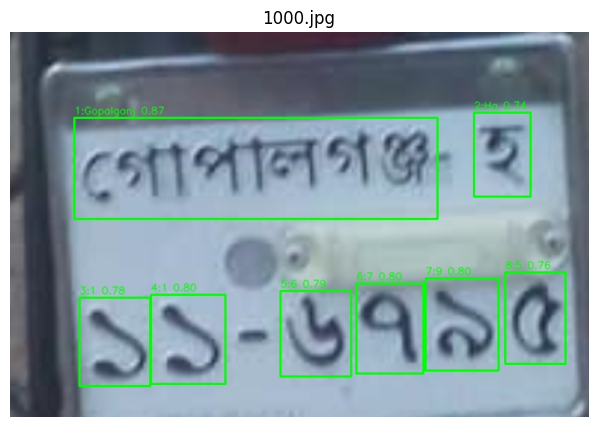

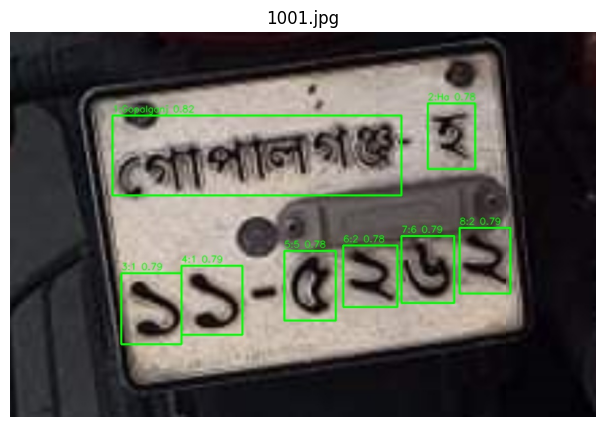

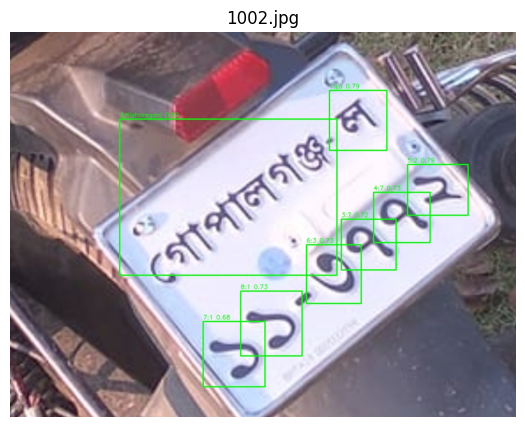

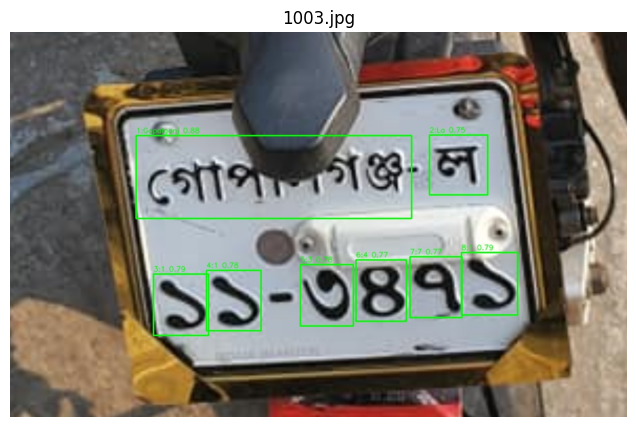

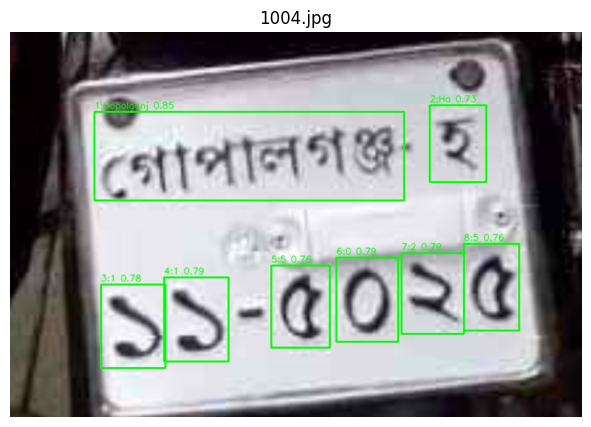

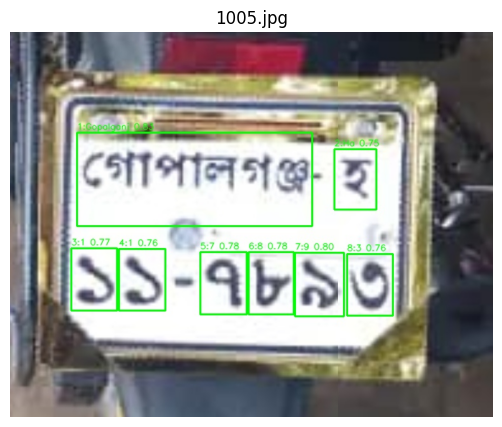


DONE.


In [17]:
# ============================================================
# 16. DISPLAY VISUALIZATIONS
# ============================================================

visual_files = sorted(
    VIS_DIR.glob("*.jpg")
)[:6]

for visual_path in visual_files:

    image = cv2.imread(
        str(visual_path)
    )

    if image is None:
        continue

    plt.figure(
        figsize=(14, 5)
    )

    plt.imshow(
        cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title(
        visual_path.name
    )

    plt.axis("off")
    plt.show()


print("\nDONE.")